/Users/arthugt/Documents/sc/norton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Iniciando o processo completo de análise exploratória...
⏳ Baixando dataset do Kaggle...
✅ Dataset baixado em: /Users/arthugt/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1
📖 Lendo o arquivo /Users/arthugt/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1/fraudTest.csv...
✅ Arquivo lido com sucesso! Total de linhas: 555719
✂️ Extraindo amostra de 10% (Passo 2)...
✅ Amostra criada com 55572 registros.
📏 Calculando distâncias geográficas (Haversine)...
🕒 Extraindo componente temporal (Hora)...
✅ Cálculos finalizados em 0.05 segundos.
📊 Gerando Gráfico 1: Boxplot...


/var/folders/4p/zw2plfkx5v59xyxbwbpbbrtw0000gn/T/ipykernel_861/1537050781.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='distancia_km', data=amostra, palette='Set2')


✅ Gráfico 1 salvo como 'grafico_distancia.png'.


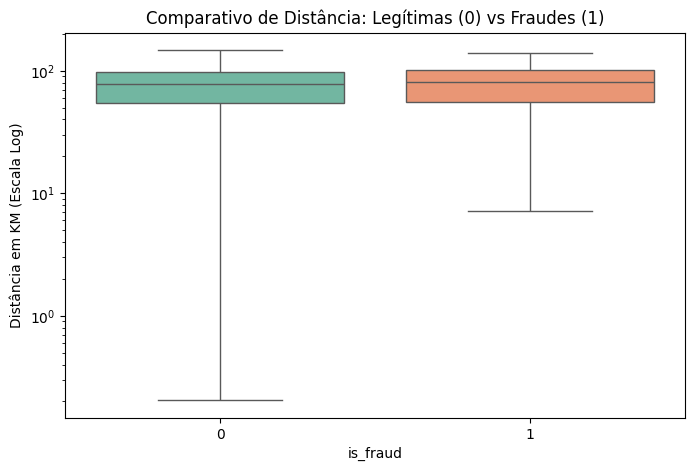

🔥 Gerando Gráfico 2: Heatmap de Fraudes (Categoria vs Hora)...
✅ Gráfico 2 salvo como 'heatmap_fraude.png'.


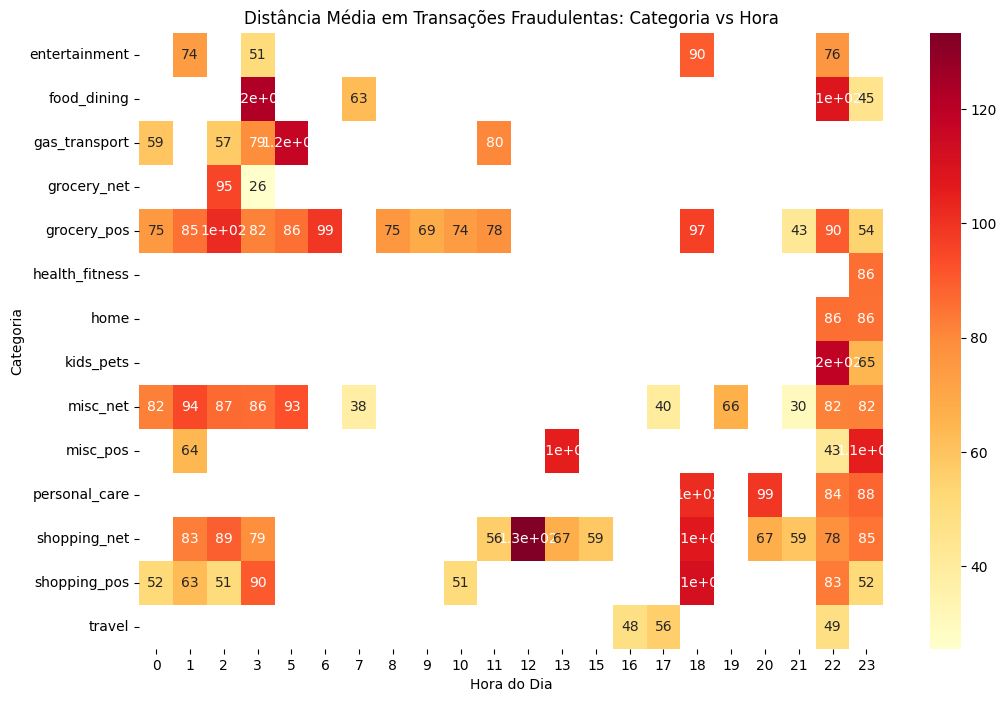


--- 📝 ESTATÍSTICAS PARA A TABELA DO OVERLEAF ---
               mean       min         max    count
is_fraud                                          
0         75.846964  0.205072  147.237488  55356.0
1         78.310152  7.100943  139.995043    216.0

🚀 Processo concluído! Lembre-se de subir os dois arquivos .png para o Overleaf.

--- 📊 TABELA DE ANOMALIAS GEOGRÁFICAS (MADRUGADA) ---
               Dist_Media_Legitima  Dist_Media_Fraude  Diferenca_Absoluta_KM
category                                                                    
food_dining              75.843264         122.740136              46.896872
misc_net                 74.918528          86.966420              12.047892
grocery_pos              75.652993          85.350925               9.697932
shopping_net             75.812583          85.022293               9.209710
gas_transport            76.251802          72.698137              -3.553665
shopping_pos             74.859135          66.991494              -7.8

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

print("🚀 Iniciando o processo completo de análise exploratória...")

# 1. DOWNLOAD DOS DADOS
print("⏳ Baixando dataset do Kaggle...")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print(f"✅ Dataset baixado em: {path}")

# 2. CARREGAMENTO (Lendo o arquivo de teste conforme seu padrão)
csv_path = os.path.join(path, "fraudTest.csv")
print(f"📖 Lendo o arquivo {csv_path}...")
df = pd.read_csv(csv_path)
print(f"✅ Arquivo lido com sucesso! Total de linhas: {len(df)}")

# 3. AMOSTRAGEM (10% conforme solicitado pelo enunciado do Norton)
print("✂️ Extraindo amostra de 10% (Passo 2)...")
amostra = df.sample(frac=0.1, random_state=42).copy() # .copy() evita avisos do pandas
print(f"✅ Amostra criada com {len(amostra)} registros.")

# 4. CÁLCULO DE DISTÂNCIA (Haversine)
print("📏 Calculando distâncias geográficas (Haversine)...")
start_time = time.time()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2.0)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2.0)**2
    return R * 2 * np.arcsin(np.sqrt(a))

amostra['distancia_km'] = haversine(amostra['lat'], amostra['long'], 
                                    amostra['merch_lat'], amostra['merch_long'])

# 5. NOVA EXTRAÇÃO: HORA DO DIA
print("🕒 Extraindo componente temporal (Hora)...")
amostra['hora'] = pd.to_datetime(amostra['unix_time'], unit='s').dt.hour

end_time = time.time()
print(f"✅ Cálculos finalizados em {end_time - start_time:.2f} segundos.")

# 6. GRÁFICO 1: BOXPLOT (Sua análise inicial)
print("📊 Gerando Gráfico 1: Boxplot...")
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_fraud', y='distancia_km', data=amostra, palette='Set2')
plt.yscale('log')
plt.title('Comparativo de Distância: Legítimas (0) vs Fraudes (1)')
plt.ylabel('Distância em KM (Escala Log)')
plt.savefig('grafico_distancia.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico 1 salvo como 'grafico_distancia.png'.")
plt.show()

# 7. GRÁFICO 2: HEATMAP (A análise multivariada para o refino)
print("🔥 Gerando Gráfico 2: Heatmap de Fraudes (Categoria vs Hora)...")
fraudes = amostra[amostra['is_fraud'] == 1]

# Criando a matriz: Distância média por Categoria e Hora
pivot_fraude = fraudes.groupby(['category', 'hora'])['distancia_km'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_fraude, cmap='YlOrRd', annot=True)
plt.title('Distância Média em Transações Fraudulentas: Categoria vs Hora')
plt.xlabel('Hora do Dia')
plt.ylabel('Categoria')
plt.savefig('heatmap_fraude.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico 2 salvo como 'heatmap_fraude.png'.")
plt.show()

# 8. RESUMO FINAL PARA O OVERLEAF
print("\n--- 📝 ESTATÍSTICAS PARA A TABELA DO OVERLEAF ---")
resumo = amostra.groupby('is_fraud')['distancia_km'].describe()
print(resumo[['mean', 'min', 'max', 'count']])

print("\n🚀 Processo concluído! Lembre-se de subir os dois arquivos .png para o Overleaf.")

# 1. Criar a métrica de madrugada (ex: 00h às 06h)
amostra['is_madrugada'] = amostra['hora'].apply(lambda x: 1 if x <= 6 else 0)

# 2. Agrupar por Categoria e Período para ver a distância média
tabela_analise = amostra.groupby(['category', 'is_madrugada', 'is_fraud'])['distancia_km'].mean().unstack(level=-1)

# 3. Renomear colunas para facilitar a leitura
tabela_analise.columns = ['Dist_Media_Legitima', 'Dist_Media_Fraude']

# 4. Calcular a diferença percentual (onde a fraude mais se distancia do padrão)
tabela_analise['Diferenca_Absoluta_KM'] = tabela_analise['Dist_Media_Fraude'] - tabela_analise['Dist_Media_Legitima']

# 5. Filtrar apenas o período da madrugada e ordenar pelas maiores anomalias
top_anomalias = tabela_analise.xs(1, level='is_madrugada').sort_values(by='Diferenca_Absoluta_KM', ascending=False)

print("\n--- 📊 TABELA DE ANOMALIAS GEOGRÁFICAS (MADRUGADA) ---")
print(top_anomalias.head(10))

# Salvar para CSV caso queira abrir no Excel/Sheets
top_anomalias.to_csv('tabela_anomalias.csv')